Using: C:\Users\Zahra\Box\UofT-UIC-\second run in UIC\IDOT-20260423T161905Z-3-001\IDOT\W065_08-17-2025\W065_08-17-2025\images\1755425701551148268-snapshot.jpg

bbox_tool.py
------------
Interactive bounding-box zone drawer for railroad-crossing flow analysis.

Usage (in a Jupyter cell or terminal):
    from bbox_tool import BBoxDrawer, load_boxes, SUGGESTED_BOXES

    # Option A – draw your own boxes interactively
    drawer = BBoxDrawer("path/to/image.jpg")
    # … click-drag to draw each zone, press 'n' to advance, 's' to save …

    # Option B – start from the pre-seeded suggestions and tweak
    drawer = BBoxDrawer("path/to/image.jpg", initial_boxes=SUGGESTED_BOXES)

Keyboard shortcuts:
  n / p  – next / previous zone
  d      – delete current zone's box
  s      – save to bounding_boxes.json
  q      – quit and save


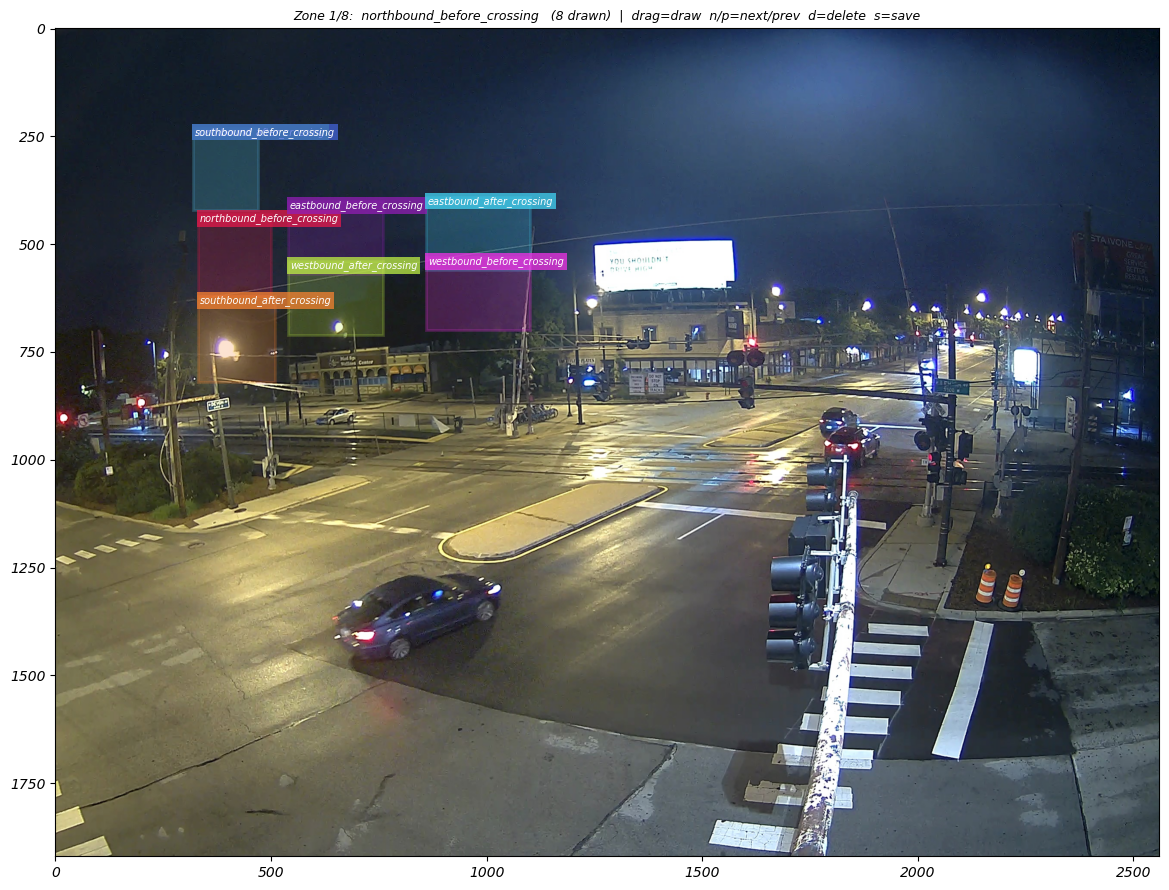

In [1]:
from pathlib import Path
from utils import get_image_file_names
from bbox_tool import BBoxDrawer, SUGGESTED_BOXES

DATA_PATH  = Path("C:/Users/Zahra/Box/UofT-UIC-/second run in UIC/IDOT-20260423T161905Z-3-001/IDOT/W065_08-17-2025/W065_08-17-2025")
IMAGE_PATH = DATA_PATH / "images"

file_paths, _, _ = get_image_file_names(IMAGE_PATH)

# Pick any frame — mid-dataset is usually a good representative
sample_image = str(file_paths[len(file_paths) // 2])
print("Using:", sample_image)   # confirm it looks right

drawer = BBoxDrawer(sample_image, initial_boxes=SUGGESTED_BOXES)

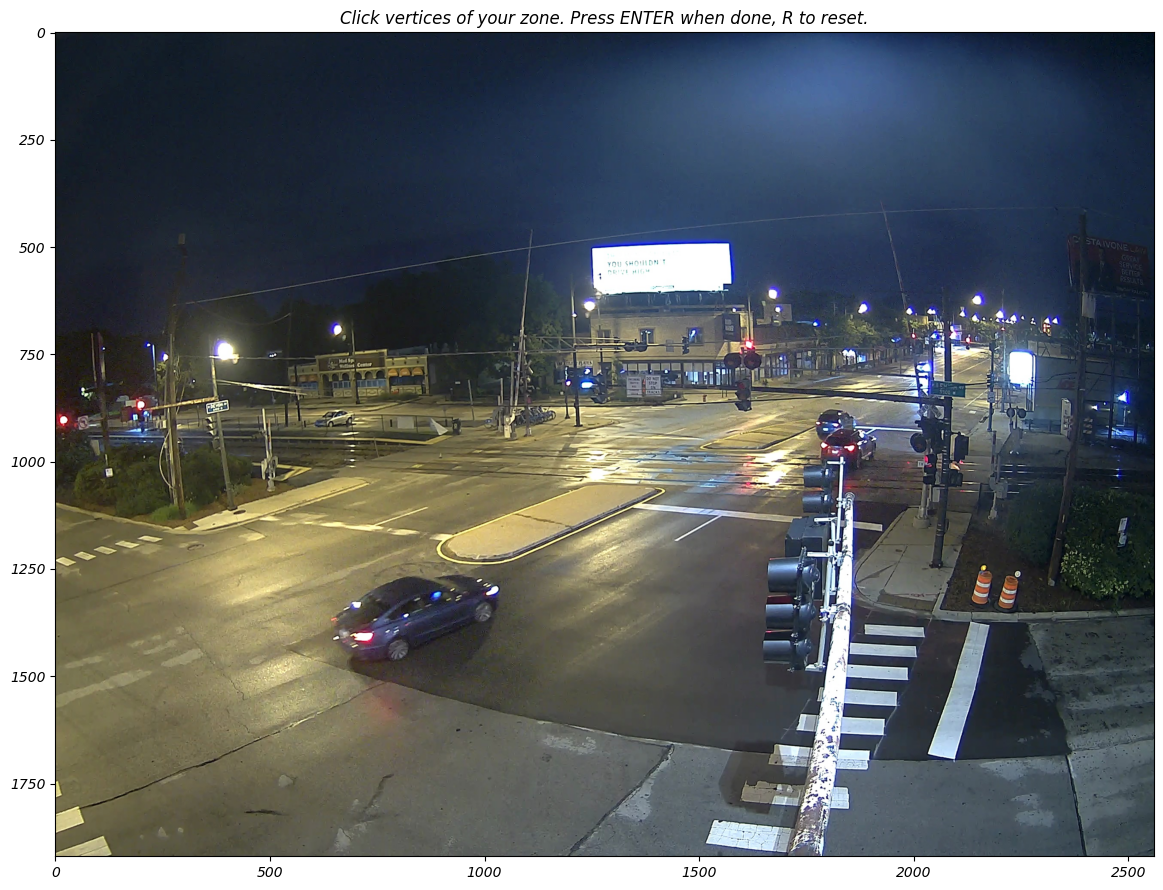

In [1]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from pathlib import Path
from utils import get_image_file_names

# 1. Your data folder path
DATA_PATH  = Path("C:/Users/Zahra/Box/UofT-UIC-/second run in UIC/IDOT-20260423T161905Z-3-001/IDOT/W065_08-17-2025/W065_08-17-2025")
IMAGE_PATH = DATA_PATH / "images"

# 2. Get the list of image files
file_paths, _, _ = get_image_file_names(IMAGE_PATH)

# 3. Pick one image from that list
img = mpimg.imread(str(file_paths[len(file_paths)//2]))
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(img)
ax.set_title("Click vertices of your zone. Press ENTER when done, R to reset.")

clicked_points = []
dots = []

def onclick(event):
    if event.inaxes != ax:
        return
    x, y = int(event.xdata), int(event.ydata)
    clicked_points.append((x, y))
    dot, = ax.plot(x, y, 'ro', markersize=6)
    dots.append(dot)
    if len(clicked_points) > 1:
        xs = [p[0] for p in clicked_points] + [clicked_points[0][0]]
        ys = [p[1] for p in clicked_points] + [clicked_points[0][1]]
        ax.plot(xs, ys, 'r-', linewidth=1.5)
    ax.set_title(f"Points so far: {clicked_points}\nEnter=done  R=reset")
    fig.canvas.draw_idle()

def onkey(event):
    if event.key == 'enter':
        print("\n✅ Copy-paste this into your notebook:\n")
        print("vertices = [")
        for p in clicked_points:
            print(f"    {p},")
        print("]")
        plt.close()
    elif event.key == 'r':
        clicked_points.clear()
        for d in dots: d.remove()
        dots.clear()
        ax.set_title("Reset. Click to start again.")
        fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_press_event', onclick)
fig.canvas.mpl_connect('key_press_event', onkey)
plt.tight_layout()
plt.show()

In [1]:
%matplotlib tk
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from utils import get_image_file_names

# ── your path ─────────────────────────────────────────────────────────────────
DATA_PATH  = Path("C:/Users/Zahra/Box/UofT-UIC-/second run in UIC/IDOT-20260423T161905Z-3-001/IDOT/W065_08-17-2025/W065_08-17-2025")
IMAGE_PATH = DATA_PATH / "images"
file_paths, _, _ = get_image_file_names(IMAGE_PATH)

# ── pick a frame ──────────────────────────────────────────────────────────────
test_image = file_paths[10]   # change index if you want a different frame

# ── interactive zone drawer ───────────────────────────────────────────────────
ZONE_NAME = "northbound_before_crossing"   # <── change this for each zone

fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(mpimg.imread(str(test_image)))
ax.set_title(f"Zone: {ZONE_NAME}  |  Click corners → Enter to confirm  |  R to reset")

pts = []

def onclick(event):
    if event.inaxes != ax: return
    x, y = int(event.xdata), int(event.ydata)
    pts.append((x, y))
    ax.plot(x, y, 'ro', markersize=7)
    if len(pts) > 1:
        ax.plot([pts[-2][0], x], [pts[-2][1], y], 'r-', lw=2)
    if len(pts) > 2:   # close the polygon preview
        ax.plot([pts[-1][0], pts[0][0]], [pts[-1][1], pts[0][1]], 'r--', lw=1, alpha=0.4)
    fig.canvas.draw_idle()

def onkey(event):
    if event.key == 'enter':
        print(f'"{ZONE_NAME}": {pts}')
        plt.close()
    elif event.key == 'r':
        pts.clear()
        ax.cla()
        ax.imshow(mpimg.imread(str(test_image)))
        ax.set_title(f"Zone: {ZONE_NAME}  |  Reset — click again")
        fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_press_event', onclick)
fig.canvas.mpl_connect('key_press_event', onkey)
plt.tight_layout()
plt.show()

"northbound_before_crossing": [(507, 1146), (802, 1021), (1203, 1057), (888, 1211), (503, 1144)]
